In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from mlxtend.frequent_patterns import apriori, association_rules

sns.set(style="whitegrid")

In [34]:
df = pd.read_csv("Global_Music_Streaming_Listener_Preferences (1).csv")
genre_country_df = df[["Country", "Top Genre"]]
genre_counts = genre_country_df.groupby(["Country", "Top Genre"]).size().reset_index(name="Count")
genre_pivot = genre_counts.pivot(index="Country", columns="Top Genre", values="Count").fillna(0)

genre_pivot
##Genre Popularity by Country

Top Genre,Classical,Country,EDM,Hip-Hop,Jazz,Metal,Pop,R&B,Reggae,Rock
Country,,,,,,,,,,
Australia,47,49,53,55,60,43,61,48,55,55
Brazil,59,53,48,39,45,44,56,57,46,61
Canada,37,51,59,51,57,38,56,54,55,49
France,42,47,50,52,59,51,35,51,55,51
Germany,45,45,71,44,44,56,37,50,37,42
India,55,49,42,54,52,45,40,45,62,46
Japan,45,55,48,48,57,51,55,41,49,42
South Korea,48,47,56,61,51,52,34,52,51,64
UK,49,42,42,47,56,58,45,59,63,55


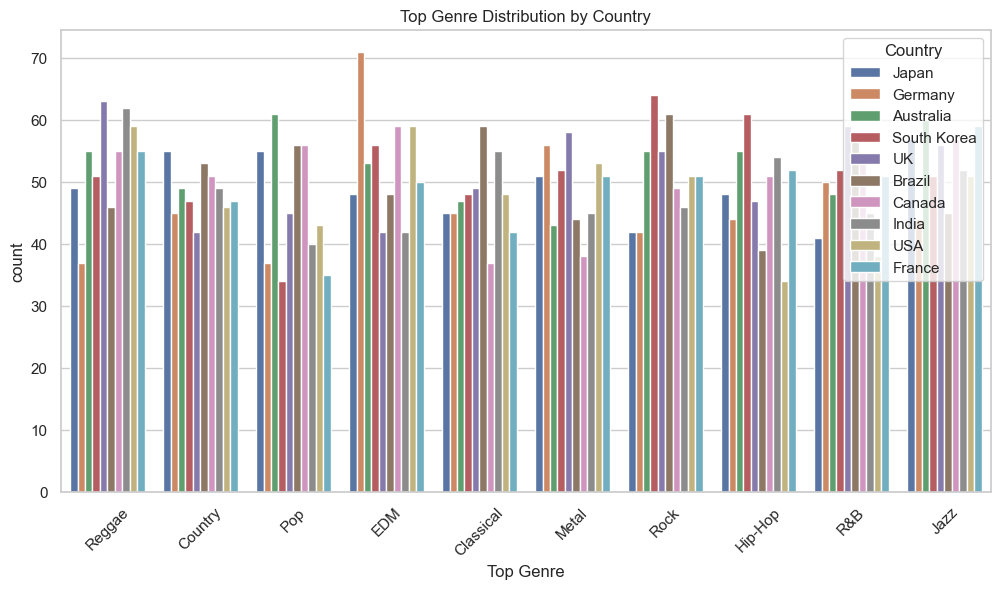

In [38]:
plt.figure(figsize=(12,6))

sns.countplot(data=df, x="Top Genre", hue="Country")

plt.title("Top Genre Distribution by Country")
plt.xticks(rotation=45)

plt.show()
#EDM is outstandingly popular in Germany

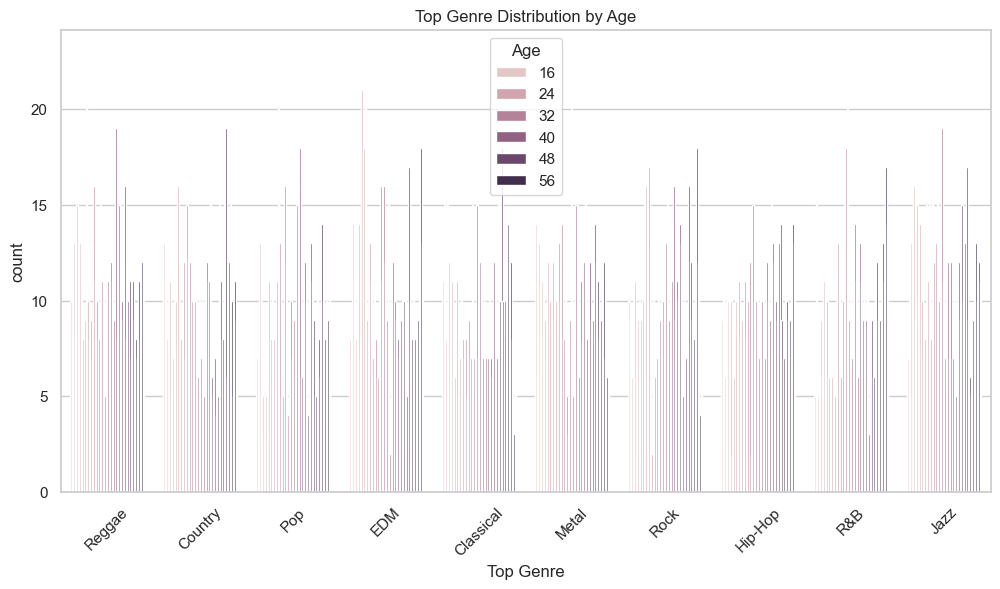

In [37]:
plt.figure(figsize=(12,6))

sns.countplot(data=df, x="Top Genre", hue="Age")

plt.title("Top Genre Distribution by Age")
plt.xticks(rotation=45)

plt.show()

In [4]:
df = df.fillna(df.mean(numeric_only=True))
df = df.fillna("Unknown")
df.isnull().sum()

User_ID                                     0
Age                                         0
Country                                     0
Streaming Platform                          0
Top Genre                                   0
Minutes Streamed Per Day                    0
Number of Songs Liked                       0
Most Played Artist                          0
Subscription Type                           0
Listening Time (Morning/Afternoon/Night)    0
Discover Weekly Engagement (%)              0
Repeat Song Rate (%)                        0
dtype: int64

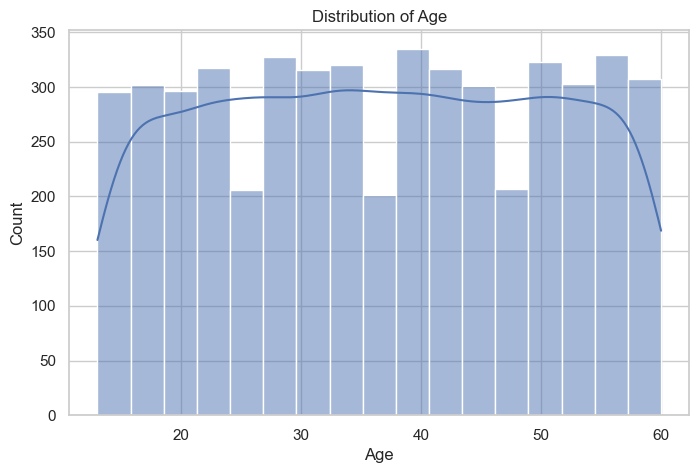

In [40]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], kde=True)
plt.title("Distribution of Age")
plt.show()

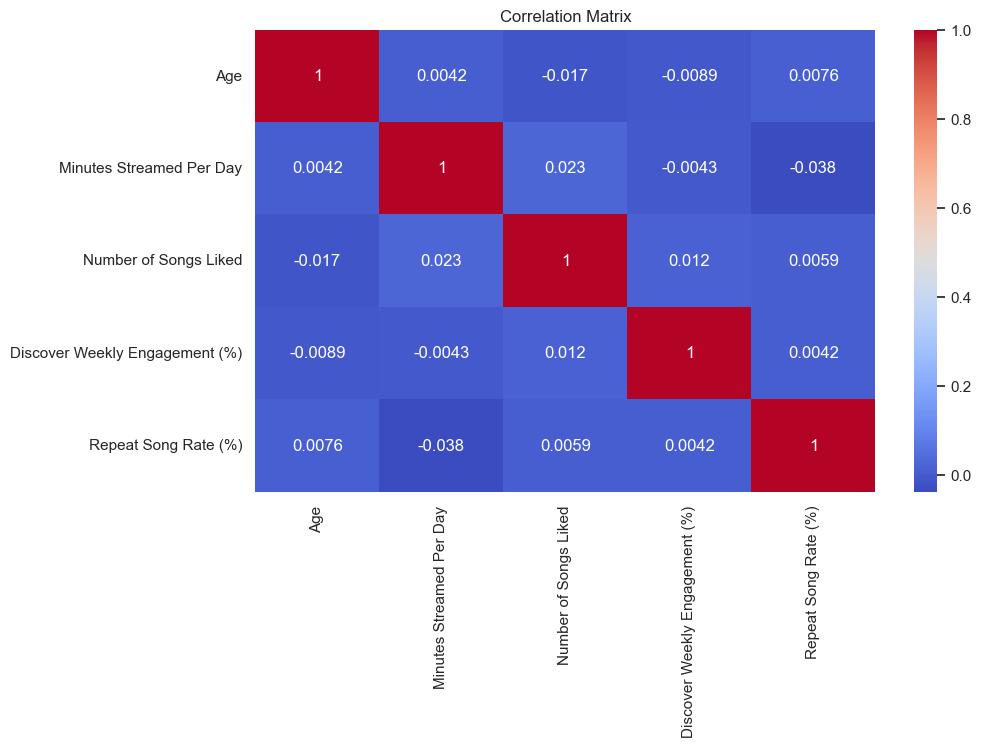

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [9]:
features = df.select_dtypes(include=[np.number])

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [10]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

df["Cluster"] = clusters

df.head()

,User_ID,Age,Country,Streaming Platform,Top Genre,Minutes Streamed Per Day,Number of Songs Liked,Most Played Artist,Subscription Type,Listening Time (Morning/Afternoon/Night),Discover Weekly Engagement (%),Repeat Song Rate (%),Cluster
0,U1000,34,Japan,Tidal,Reggae,295,138,Adele,Free,Afternoon,47.42,16.74,2
1,U1001,24,Germany,Deezer,Country,86,388,Ed Sheeran,Premium,Night,12.06,69.25,0
2,U1002,49,Germany,Deezer,Pop,363,368,Post Malone,Premium,Afternoon,47.19,67.38,0
3,U1003,55,Australia,YouTube,Reggae,348,349,Dua Lipa,Premium,Morning,31.27,76.51,0
4,U1004,13,Germany,Amazon Music,Reggae,30,328,Adele,Free,Night,30.68,43.41,2


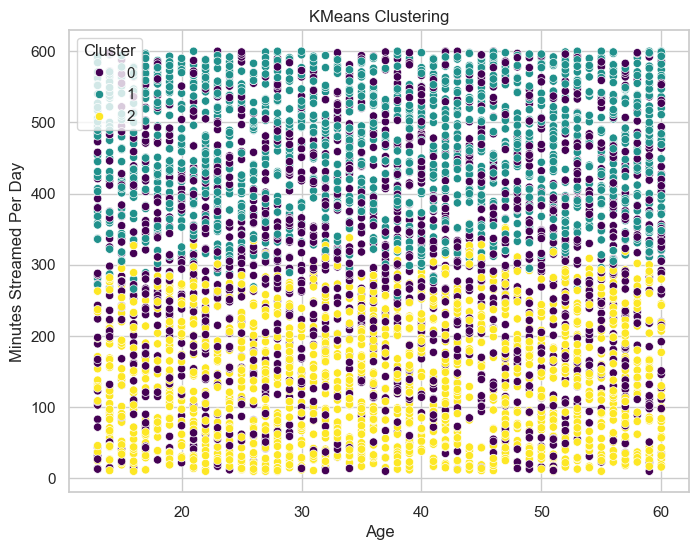

In [11]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=features.iloc[:,0],
    y=features.iloc[:,1],
    hue=df["Cluster"],
    palette="viridis"
)

plt.title("KMeans Clustering")
plt.show()

In [12]:
basket = df.astype(bool)

frequent_itemsets = apriori(basket, min_support=0.05, use_colnames=True)

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)

rules.head()

C:\Users\lisbe\miniconda3\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({User_ID}),frozenset({Age}),1.0,1.0,1.0,1.0,1.0,1.0,0.0,inf,0.0,1.0,0.0,1.0
1,frozenset({Age}),frozenset({User_ID}),1.0,1.0,1.0,1.0,1.0,1.0,0.0,inf,0.0,1.0,0.0,1.0
2,frozenset({User_ID}),frozenset({Country}),1.0,1.0,1.0,1.0,1.0,1.0,0.0,inf,0.0,1.0,0.0,1.0
3,frozenset({Country}),frozenset({User_ID}),1.0,1.0,1.0,1.0,1.0,1.0,0.0,inf,0.0,1.0,0.0,1.0
4,frozenset({User_ID}),frozenset({Streaming Platform}),1.0,1.0,1.0,1.0,1.0,1.0,0.0,inf,0.0,1.0,0.0,1.0


In [13]:
basket = df.astype(bool)

frequent_itemsets = apriori(basket, min_support=0.05, use_colnames=True)

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)

rules.head()

C:\Users\lisbe\miniconda3\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({User_ID}),frozenset({Age}),1.0,1.0,1.0,1.0,1.0,1.0,0.0,inf,0.0,1.0,0.0,1.0
1,frozenset({Age}),frozenset({User_ID}),1.0,1.0,1.0,1.0,1.0,1.0,0.0,inf,0.0,1.0,0.0,1.0
2,frozenset({User_ID}),frozenset({Country}),1.0,1.0,1.0,1.0,1.0,1.0,0.0,inf,0.0,1.0,0.0,1.0
3,frozenset({Country}),frozenset({User_ID}),1.0,1.0,1.0,1.0,1.0,1.0,0.0,inf,0.0,1.0,0.0,1.0
4,frozenset({User_ID}),frozenset({Streaming Platform}),1.0,1.0,1.0,1.0,1.0,1.0,0.0,inf,0.0,1.0,0.0,1.0


In [18]:
import os
os.getcwd()

'C:\\Users\\lisbe'

In [14]:
print(df.columns)

Index(['User_ID', 'Age', 'Country', 'Streaming Platform', 'Top Genre',
       'Minutes Streamed Per Day', 'Number of Songs Liked',
       'Most Played Artist', 'Subscription Type',
       'Listening Time (Morning/Afternoon/Night)',
       'Discover Weekly Engagement (%)', 'Repeat Song Rate (%)', 'Cluster'],
      dtype='str')
